<a href="https://colab.research.google.com/github/iotsync2420/Diffusion_txt2img/blob/main/diffusion_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
!pip install diffusers transformers accelerate -q

In [47]:
import socket
try:
    print("DNS lookup test:", socket.gethostbyname("8.8.8.8"))
    print("Google DNS resolve test:", socket.gethostbyname("google.com"))
    print("✅ Colab internet connection is active.")
except Exception as e:
    print("❌ Total Network Blocked in Colab:", e)

DNS lookup test: 8.8.8.8
Google DNS resolve test: 74.125.24.138
✅ Colab internet connection is active.


In [48]:
%%writefile generate.py
import requests
import io
from PIL import Image

MODELS = {
    "Stable Diffusion 1.5": "runwayml/stable-diffusion-v1-5",
    "SDXL": "stabilityai/stable-diffusion-xl-base-1.0",
}

STYLE_PRESETS = {
    "None": "",
    "Photorealistic": "photorealistic, DSLR, 8K, sharp focus, detailed",
    "Anime": "anime style, Studio Ghibli, vibrant colors, illustrated",
    "Oil Painting": "oil painting, brush strokes, classical art, canvas texture",
    "Watercolor": "watercolor painting, soft edges, pastel colors, artistic",
    "Cyberpunk": "cyberpunk, neon lights, futuristic, dark city, rain",
}

def generate_text2img(prompt, negative_prompt, hf_token, model_key="Stable Diffusion 1.5", style_key="None"):
    model_id = MODELS[model_key]
    API_URL = f"https://104.18.23.235/models/{model_id}"
    headers = {
    "Authorization": f"Bearer {hf_token}",
    "Host": "api-inference.huggingface.co"
}

    # Apply style preset if selected
    style_suffix = STYLE_PRESETS.get(style_key, "")
    final_prompt = f"{prompt}, {style_suffix}" if style_suffix else prompt

    payload = {
        "inputs": final_prompt,
        "parameters": {"negative_prompt": negative_prompt}
    }

    response = requests.post(API_URL, headers=headers, json=payload)
    if response.status_code == 200:
        return Image.open(io.BytesIO(response.content)), None
    return None, f"Error {response.status_code}: {response.text}"

def generate_img2img(image, prompt, hf_token, model_key="Stable Diffusion 1.5"):
    """
    Hugging Face Inference API img2img requires sending the raw image bytes
    as the main data payload, and secondary inputs (like the prompt) via headers
    or special parameter mapping depending on the endpoint backend.
    """
    model_id = MODELS[model_key]
    API_URL = f"https://api-inference.huggingface.co/models/{model_id}"

    # For serverless API img2img, headers mapping parameters is often the cleanest fallback
    # or passing a multipart payload.
    headers = {
        "Authorization": f"Bearer {hf_token}",
    }

    # Convert PIL Image to raw bytes
    buffered = io.BytesIO()
    image.save(buffered, format="JPEG")
    img_bytes = buffered.getvalue()

    # Form data payload structure for HF image-to-image
    files = {
        "image": ("image.jpeg", img_bytes, "image/jpeg")
    }
    data = {
        "prompt": prompt
    }

    response = requests.post(API_URL, headers=headers, files=files, data=data)

    if response.status_code == 200:
        return Image.open(io.BytesIO(response.content)), None
    return None, f"Error {response.status_code}: {response.text}"

Overwriting generate.py


In [49]:
%%writefile app.py
import streamlit as st
from generate import generate_text2img, generate_img2img, STYLE_PRESETS, MODELS
from PIL import Image
import datetime
import io

st.set_page_config(page_title="DreamForge AI", page_icon="🎨", layout="wide")
st.title("🎨 DreamForge — AI Image Generator")
st.caption("Powered by Stable Diffusion via Hugging Face")

# Initialize Session States
if "history" not in st.session_state:
    st.session_state.history = []

# Initialize the main prompt tracking variable explicitly
if "main_prompt_input" not in st.session_state:
    st.session_state.main_prompt_input = ""

# ── Sidebar ──────────────────────────────────────────
with st.sidebar:
    st.header("⚙️ Settings")
    hf_token = st.text_input("🔑 HF Token", type="password")
    st.markdown("[Get free token →](https://huggingface.co/settings/tokens)")

    model_choice = st.selectbox("Model", list(MODELS.keys()))
    mode = st.radio("Mode", ["Text → Image", "Image → Image"])

    st.divider()
    st.header("🕓 Prompt History")

    if st.session_state.history:
        # Loop over a static copied slice to avoid index shifting mutation bugs
        for i, item in enumerate(reversed(st.session_state.history[-5:])):
            st.caption(f"🕐 {item['time']}")
            st.write(f"_{item['prompt'][:60]}..._" if len(item['prompt']) > 60 else f"_{item['prompt']}_")

            # Directly mutate the text area key to instantly force update the widget state
            if st.button("Reuse", key=f"reuse_{i}"):
                st.session_state.main_prompt_input = item['prompt']
                st.rerun()
    else:
        st.caption("No history yet.")

# ── Main Area ─────────────────────────────────────────
col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("📝 Prompt")

    # Using the state-tied key here directly solves the reuse sync glitch
    prompt = st.text_area("Prompt", key="main_prompt_input", height=100)
    neg_prompt = st.text_input("Negative Prompt", "blurry, low quality, deformed, ugly")
    style = st.selectbox("🎨 Style Preset", list(STYLE_PRESETS.keys()))

    uploaded = None
    if mode == "Image → Image":
        uploaded = st.file_uploader("Upload Image to Transform", type=["png", "jpg", "jpeg"])

    generate_btn = st.button("✨ Generate", use_container_width=True, type="primary")

with col2:
    st.subheader("🖼️ Output")
    output_placeholder = st.empty()

    if generate_btn:
        if not hf_token:
            st.error("Please enter your HF Token in the sidebar!")
        elif not prompt:
            st.error("Please enter a prompt!")
        else:
            with st.spinner("Generating your image... ✨"):
                if mode == "Text → Image":
                    # Let generate_text2img handle the style parsing implicitly
                    image, error = generate_text2img(
                        prompt, neg_prompt, hf_token, model_choice, style_key=style
                    )
                else:
                    if not uploaded:
                        st.error("Please upload an image!")
                        image, error = None, None
                    else:
                        input_img = Image.open(uploaded)
                        # Let generate_img2img take the raw prompt input
                        image, error = generate_img2img(input_img, prompt, hf_token, model_choice)

                if error:
                    st.error(error)
                elif image:
                    output_placeholder.image(image, use_container_width=True)

                    # Save to history
                    st.session_state.history.append({
                        "prompt": prompt,
                        "time": datetime.datetime.now().strftime("%H:%M:%S"),
                        "style": style
                    })

                    # Streamlined buffer management
                    buf = io.BytesIO()
                    image.save(buf, format="PNG")
                    st.download_button(
                        "⬇️ Download Image",
                        buf.getvalue(),
                        "dreamforge_output.png",
                        "image/png",
                        use_container_width=True
                    )

Overwriting app.py


In [50]:
%%writefile requirements.txt
streamlit
Pillow
requests
diffusers
transformers
accelerate

Overwriting requirements.txt


In [51]:
%%writefile generate.py
import requests
import io
from PIL import Image

MODELS = {
    "Stable Diffusion 1.5": "runwayml/stable-diffusion-v1-5",
    "SDXL": "stabilityai/stable-diffusion-xl-base-1.0",
}

STYLE_PRESETS = {
    "None": "",
    "Photorealistic": "photorealistic, DSLR, 8K, sharp focus, detailed",
    "Anime": "anime style, Studio Ghibli, vibrant colors, illustrated",
    "Oil Painting": "oil painting, brush strokes, classical art, canvas texture",
    "Watercolor": "watercolor painting, soft edges, pastel colors, artistic",
    "Cyberpunk": "cyberpunk, neon lights, futuristic, dark city, rain",
}

def generate_text2img(prompt, negative_prompt, hf_token, model_key="Stable Diffusion 1.5", style_key="None"):
    model_id = MODELS[model_key]
    API_URL = f"https://api-inference.huggingface.co/models/{model_id}" # Corrected API URL
    headers = {
    "Authorization": f"Bearer {hf_token}",
    "Host": "api-inference.huggingface.co"
}

    # Apply style preset if selected
    style_suffix = STYLE_PRESETS.get(style_key, "")
    final_prompt = f"{prompt}, {style_suffix}" if style_suffix else prompt

    payload = {
        "inputs": final_prompt,
        "parameters": {"negative_prompt": negative_prompt}
    }

    response = requests.post(API_URL, headers=headers, json=payload)
    if response.status_code == 200:
        return Image.open(io.BytesIO(response.content)), None
    return None, f"Error {response.status_code}: {response.text}"

def generate_img2img(image, prompt, hf_token, model_key="Stable Diffusion 1.5"):
    """
    Hugging Face Inference API img2img requires sending the raw image bytes
    as the main data payload, and secondary inputs (like the prompt) via headers
    or special parameter mapping depending on the endpoint backend.
    """
    model_id = MODELS[model_key]
    API_URL = f"https://api-inference.huggingface.co/models/{model_id}" # Corrected API URL for consistency

    headers = {
        "Authorization": f"Bearer {hf_token}",
    }

    # Convert PIL Image to raw bytes
    buffered = io.BytesIO()
    image.save(buffered, format="JPEG")
    img_bytes = buffered.getvalue()

    # Form data payload structure for HF image-to-image
    files = {
        "image": ("image.jpeg", img_bytes, "image/jpeg")
    }
    data = {
        "prompt": prompt
    }

    response = requests.post(API_URL, headers=headers, files=files, data=data)

    if response.status_code == 200:
        return Image.open(io.BytesIO(response.content)), None
    return None, f"Error {response.status_code}: {response.text}"

import importlib
import generate
# This forces Colab to read the brand new version of generate.py on disk
importlib.reload(generate)

from generate import generate_text2img
from google.colab import userdata

try:
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    print("Make sure to add 'HF_TOKEN' to your Colab Secrets!")
    HF_TOKEN = ""

if HF_TOKEN:
    image, error = generate_text2img(
        prompt="a futuristic city at sunset, cinematic 8K",
        negative_prompt="blurry, low quality",
        hf_token=HF_TOKEN,
        model_key="Stable Diffusion 1.5",
        style_key="None"
    )

    if error:
        print("❌ Error:", error)
    else:
        display(image)
        image.save("test_output.png")
        print("✅ Generation works perfectly!")

Overwriting generate.py


In [52]:
!pip install -r requirements.txt

In [53]:
!df -h /

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

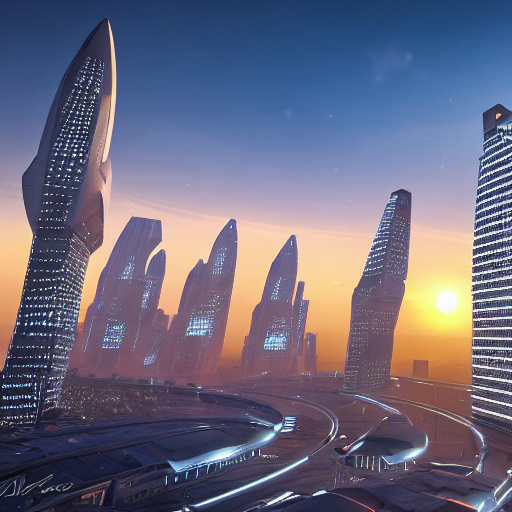

In [54]:
import torch
from diffusers import StableDiffusionPipeline
import gc

# 1. Clear out any residual memory clutter from previous failed runs
torch.cuda.empty_cache()
gc.collect()

model_id = "runwayml/stable-diffusion-v1-5"

# 2. Use torch.float16 (cuts memory usage in half)
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    use_safetensors=True  # Safetensors loads models faster and cleaner
)
pipe = pipe.to("cuda")

# 3. ENABLE MEMORY EFFICIENT ATTENTION (Essential for free-tier Colab RAM limits)
pipe.enable_attention_slicing()

prompt = "a futuristic city at sunset, cinematic 8K"
negative_prompt = "blurry, low quality"

# 4. Generate the image safely
with torch.inference_mode():
    image = pipe(prompt=prompt, negative_prompt=negative_prompt).images[0]

display(image)
image.save("local_test_output.png")